# Phishing Website Detection — URL Structural Feature Classifier
### Detectron AI · Module 14

This notebook engineers structural URL features (IP-as-host, subdomain count, TLD risk,
hyphenation, brand spoofing, HTTPS presence) and trains a **Random Forest classifier**
to detect phishing URLs, comparing it against the transparent heuristic scorer used in
the live web demo.


In [1]:
import re
import numpy as np
import pandas as pd
from urllib.parse import urlparse
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


## 1. Labeled URL dataset

In [2]:
urls = [
    ("http://paypal-secure-login.verify-account.tk", 1),
    ("http://192.168.45.12/login/secure/update", 1),
    ("http://amazon-account-verify.security-check.ml", 1),
    ("http://www.faceb00k-login.com", 1),
    ("http://apple.id.verify-now.support.xyz", 1),
    ("http://netflix-billing-update.account-alert.club", 1),
    ("http://secure-bank-login.verify.top", 1),
    ("http://micros0ft-support-update.info", 1),
    ("http://www.instagram-recovery.secure-login.ga", 1),
    ("http://whatsapp-verify-account.cf", 1),
    ("https://www.amazon.com/orders", 0),
    ("https://www.google.com/search?q=weather", 0),
    ("https://github.com/torvalds/linux", 0),
    ("https://www.wikipedia.org/wiki/Machine_learning", 0),
    ("https://mail.google.com/mail/u/0", 0),
    ("https://www.microsoft.com/en-us", 0),
    ("https://www.bbc.com/news", 0),
    ("https://stackoverflow.com/questions", 0),
    ("https://www.nytimes.com/section/technology", 0),
    ("https://www.linkedin.com/feed", 0),
]

df_raw = pd.DataFrame(urls, columns=["url", "label"])
df_raw


,url,label
0,http://paypal-secure-login.verify-account.tk,1
1,http://192.168.45.12/login/secure/update,1
2,http://amazon-account-verify.security-check.ml,1
3,http://www.faceb00k-login.com,1
4,http://apple.id.verify-now.support.xyz,1
5,http://netflix-billing-update.account-alert.club,1
6,http://secure-bank-login.verify.top,1
7,http://micros0ft-support-update.info,1
8,http://www.instagram-recovery.secure-login.ga,1
9,http://whatsapp-verify-account.cf,1


## 2. Feature engineering

In [3]:
SUSPICIOUS_TLDS = {"tk","ml","ga","cf","gq","xyz","top","club","info"}
BRANDS = ["paypal","amazon","google","microsoft","apple","netflix","facebook","instagram","whatsapp"]

def extract_features(raw_url):
    url = raw_url if re.match(r'^https?://', raw_url) else 'http://' + raw_url
    parsed = urlparse(url)
    host = parsed.hostname or ""
    is_ip = bool(re.match(r'^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$', host))
    subdomain_count = max(0, host.count('.') - 1)
    tld = host.split('.')[-1] if '.' in host else ''
    hyphens = host.count('-')
    brand_spoof = 0
    for b in BRANDS:
        if b in host and host not in (f"{b}.com", f"www.{b}.com"):
            brand_spoof = 1
            break
    has_https = int(parsed.scheme == "https")
    has_at = int('@' in url)
    host_len = len(host)
    suspicious_tld = int(tld in SUSPICIOUS_TLDS)
    return pd.Series({
        "is_ip": int(is_ip), "subdomain_count": subdomain_count, "suspicious_tld": suspicious_tld,
        "hyphens": hyphens, "brand_spoof": brand_spoof, "has_https": has_https,
        "has_at_symbol": has_at, "host_length": host_len
    })

features_df = df_raw["url"].apply(extract_features)
df = pd.concat([df_raw, features_df], axis=1)
df


,url,label,is_ip,subdomain_count,suspicious_tld,hyphens,brand_spoof,has_https,has_at_symbol,host_length
0,http://paypal-secure-login.verify-account.tk,1,0,1,1,3,1,0,0,37
1,http://192.168.45.12/login/secure/update,1,1,2,0,0,0,0,0,13
2,http://amazon-account-verify.security-check.ml,1,0,1,1,3,1,0,0,39
3,http://www.faceb00k-login.com,1,0,1,0,1,0,0,0,22
4,http://apple.id.verify-now.support.xyz,1,0,3,1,1,1,0,0,31
5,http://netflix-billing-update.account-alert.club,1,0,1,1,3,1,0,0,41
6,http://secure-bank-login.verify.top,1,0,1,1,2,0,0,0,28
7,http://micros0ft-support-update.info,1,0,0,1,2,0,0,0,29
8,http://www.instagram-recovery.secure-login.ga,1,0,2,1,2,1,0,0,38
9,http://whatsapp-verify-account.cf,1,0,0,1,2,1,0,0,26


## 3. Train Random Forest classifier

In [4]:
feature_cols = ["is_ip","subdomain_count","suspicious_tld","hyphens","brand_spoof","has_https","has_at_symbol","host_length"]
X, y = df[feature_cols], df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
clf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=42)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print(classification_report(y_test, pred, target_names=["legitimate", "phishing"]))


              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00         3
    phishing       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



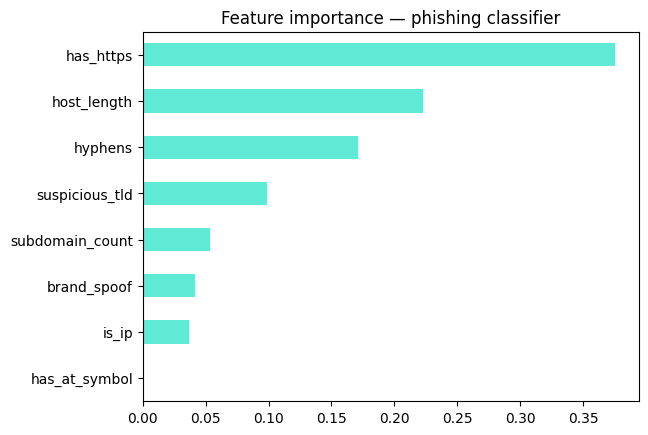

In [5]:
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind="barh", color="#5EEAD4")
plt.title("Feature importance — phishing classifier")
plt.show()


## 4. Transparent heuristic scorer (matches the live web demo)

In [6]:
def analyze_phishing_url(raw_url):
    f = extract_features(raw_url)
    risk, signals = 0, []
    if f.is_ip: risk += 30; signals.append("Raw IP address as host")
    if f.subdomain_count >= 3: risk += 20; signals.append(f"Excessive subdomains ({f.subdomain_count})")
    if f.suspicious_tld: risk += 15; signals.append("Uncommon/high-abuse TLD")
    if f.hyphens >= 2: risk += 12; signals.append(f"Multiple hyphens ({f.hyphens})")
    if f.brand_spoof: risk += 30; signals.append("Brand name used outside official domain")
    if not f.has_https: risk += 10; signals.append("No HTTPS encryption")
    if f.has_at_symbol: risk += 25; signals.append("'@' symbol in URL")
    if f.host_length > 30: risk += 10; signals.append("Unusually long domain")
    risk = min(100, risk)
    verdict = "likely phishing" if risk >= 50 else "suspicious" if risk >= 25 else "likely safe"
    return risk, verdict, signals

risk, verdict, signals = analyze_phishing_url("http://paypal-secure-login.verify-account.tk")
print(f"Risk: {risk}/100 -> {verdict.upper()}")
for s in signals: print(" -", s)


Risk: 77/100 -> LIKELY PHISHING
 - Uncommon/high-abuse TLD
 - Multiple hyphens (3)
 - Brand name used outside official domain
 - No HTTPS encryption
 - Unusually long domain


## Notes

- The Random Forest learns which combinations of structural features best predict
  phishing from labeled examples, while the heuristic scorer encodes known phishing
  patterns (IP hosts, brand spoofing, suspicious TLDs) directly and transparently.
- Production anti-phishing systems (e.g. Google Safe Browsing) combine structural URL
  features like these with real-time blocklists, page-content analysis, and certificate
  transparency logs for far stronger coverage than URL structure alone.
